# Part 1 — Baseline Crop Classification Model (MCTNet)


## 1. Imports & Configuration

In [1]:
import os
import re
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')


DATA_DIR = r'C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Crop-Classification\Data'
AR_PATH  = os.path.join(DATA_DIR, 'sentinel', 'arkansas.csv')
CA_PATH  = os.path.join(DATA_DIR, 'sentinel', 'california.csv')
SAVE_DIR = DATA_DIR
os.makedirs(SAVE_DIR, exist_ok=True)


N_TIMESTEPS = 36
N_BANDS     = 10
BAND_ORDER  = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
DOY         = [(i + 1) * 10 for i in range(N_TIMESTEPS)]
META_COLS   = ['label', 'crop_name', 'lat', 'lon',
               'latitude', 'longitude', 'system:index', '.geo', 'crop_id']

N_STAGES     = 3
N_HEADS      = 5
KERNEL_SIZE  = 3
LR           = 0.001
N_EPOCHS     = 200
BATCH_SIZE   = 32
DROPOUT      = 0.1
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

PAPER_AR = {'OA': 0.968, 'Kappa': 0.951, 'F1': 0.933}
PAPER_CA = {'OA': 0.852, 'Kappa': 0.806, 'F1': 0.829}

df_ar = pd.read_csv(AR_PATH)
df_ca = pd.read_csv(CA_PATH)

print('Arkansas')
print(f'  Shape   : {df_ar.shape}')
print(f'  Classes : {df_ar["crop_name"].value_counts().to_dict()}')

print('\nCalifornia')
print(f'  Shape   : {df_ca.shape}')
print(f'  Classes : {df_ca["crop_name"].value_counts().to_dict()}')

Device  : cpu
PyTorch : 2.11.0+cpu
Arkansas
  Shape   : (10000, 364)
  Classes : {'Soybeans': 4768, 'Rice': 2430, 'Corn': 1320, 'Cotton': 1052, 'Others': 430}

California
  Shape   : (10000, 364)
  Classes : {'Others': 3842, 'Grapes': 3471, 'Rice': 1347, 'Almonds': 585, 'Pistachios': 454, 'Alfalfa': 301}


## 2. Data Loading

In [2]:
df_ar = pd.read_csv(AR_PATH)
df_ca = pd.read_csv(CA_PATH)

print('Arkansas')
print(f'  Shape   : {df_ar.shape}')
print(f'  Classes : {df_ar["crop_name"].value_counts().to_dict()}')

print('\nCalifornia')
print(f'  Shape   : {df_ca.shape}')
print(f'  Classes : {df_ca["crop_name"].value_counts().to_dict()}')

Arkansas
  Shape   : (10000, 364)
  Classes : {'Soybeans': 4768, 'Rice': 2430, 'Corn': 1320, 'Cotton': 1052, 'Others': 430}

California
  Shape   : (10000, 364)
  Classes : {'Others': 3842, 'Grapes': 3471, 'Rice': 1347, 'Almonds': 585, 'Pistachios': 454, 'Alfalfa': 301}


## 3. Data Exploration

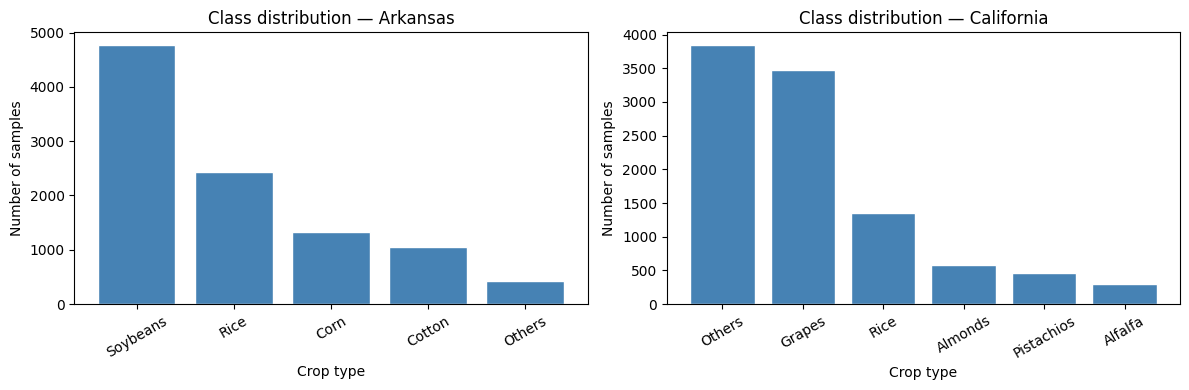

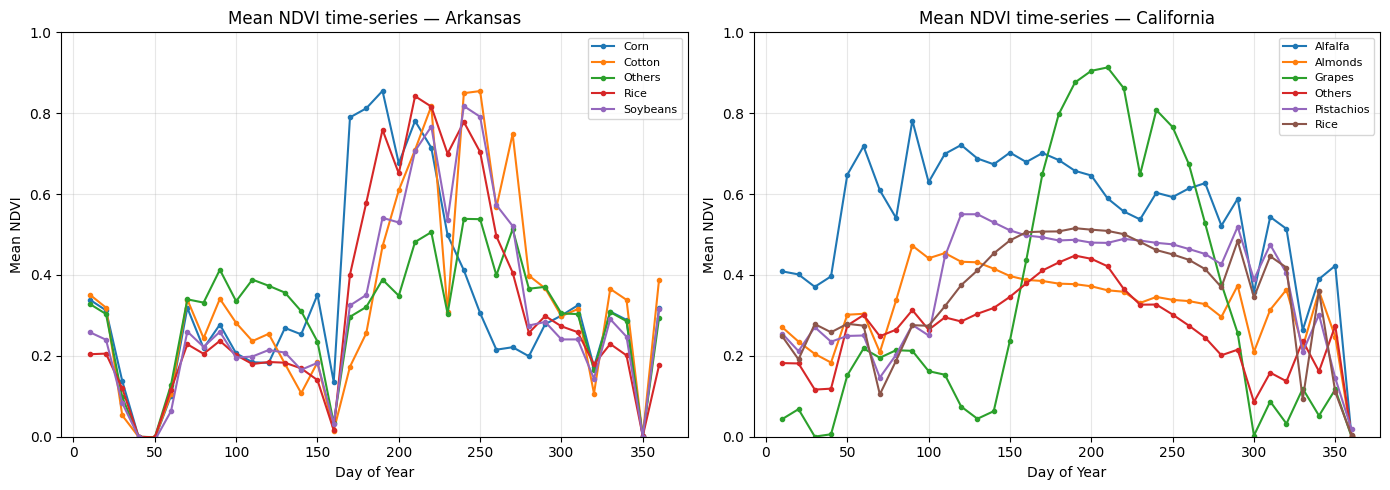

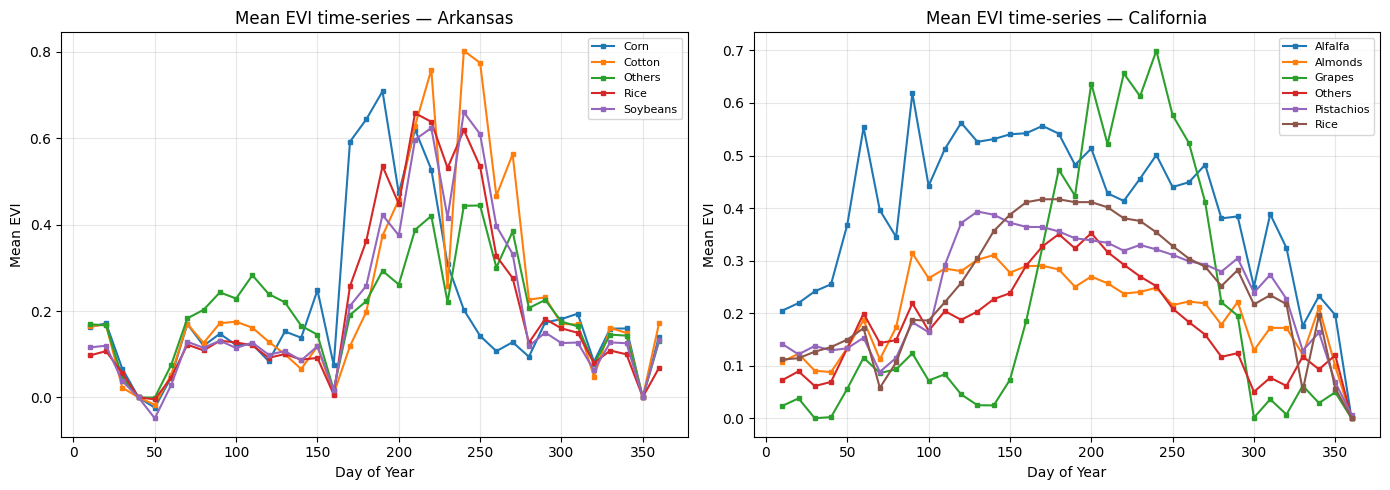

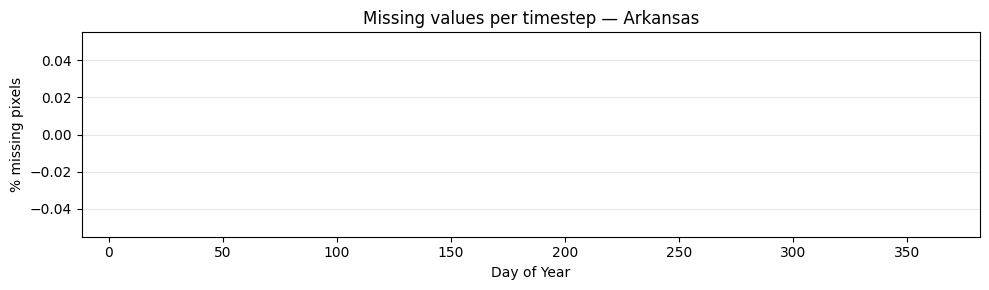

Arkansas: avg missing rate = 0.0%


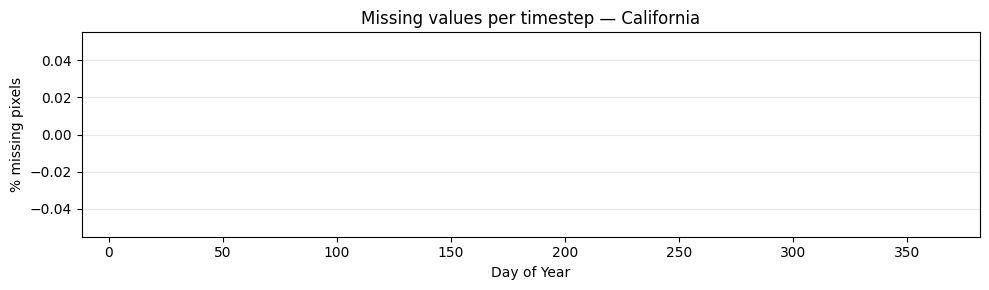

California: avg missing rate = 0.0%


In [3]:
def get_feature_cols(df):
    return [c for c in df.columns if c not in META_COLS]


def sort_feature_columns(feat_cols):
    def sort_key(col):
        m     = re.search(r'_t(\d+)$', col)
        t_idx = int(m.group(1)) if m else 0
        band  = re.sub(r'_t\d+$', '', col)
        b_idx = BAND_ORDER.index(band) if band in BAND_ORDER else 99
        return (t_idx, b_idx)
    return sorted(feat_cols, key=sort_key)


def compute_ndvi(X):
    B8 = X[:, :, 6]
    B4 = X[:, :, 2]
    return (B8 - B4) / (B8 + B4 + 1e-8)


def compute_evi(X):
    B2 = X[:, :, 0]
    B4 = X[:, :, 2]
    B8 = X[:, :, 6]
    return 2.5 * (B8 - B4) / (B8 + 6 * B4 - 7.5 * B2 + 1 + 1e-8)


def reshape_data(df):
    feat_cols = sort_feature_columns(get_feature_cols(df))
    X = df[feat_cols].values.reshape(-1, N_TIMESTEPS, N_BANDS).astype(np.float32)
    return X


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, region in zip(axes, [df_ar, df_ca], ['Arkansas', 'California']):
    counts = df['crop_name'].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Class distribution — {region}')
    ax.set_xlabel('Crop type')
    ax.set_ylabel('Number of samples')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, region in zip(axes, [df_ar, df_ca], ['Arkansas', 'California']):
    X = reshape_data(df)
    ndvi = compute_ndvi(X)

    for crop in df['crop_name'].unique():
        idx = df['crop_name'].values == crop
        mean_ndvi = ndvi[idx].mean(axis=0)
        ax.plot(DOY, mean_ndvi, marker='o', markersize=3, label=crop)

    ax.set_title(f'Mean NDVI time-series — {region}')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Mean NDVI')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, region in zip(axes, [df_ar, df_ca], ['Arkansas', 'California']):
    X = reshape_data(df)
    evi = compute_evi(X)

    for crop in df['crop_name'].unique():
        idx = df['crop_name'].values == crop
        mean_evi = evi[idx].mean(axis=0)
        ax.plot(DOY, mean_evi, marker='s', markersize=3, label=crop)

    ax.set_title(f'Mean EVI time-series — {region}')
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Mean EVI')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


for df, region in zip([df_ar, df_ca], ['Arkansas', 'California']):
    feat_cols = sort_feature_columns(get_feature_cols(df))
    X_raw = df[feat_cols].values.reshape(-1, N_TIMESTEPS, N_BANDS)
    missing_per_t = np.isnan(X_raw).any(axis=2).mean(axis=0) * 100

    plt.figure(figsize=(10, 3))
    plt.bar(DOY, missing_per_t, color='salmon', width=8)
    plt.title(f'Missing values per timestep — {region}')
    plt.xlabel('Day of Year')
    plt.ylabel('% missing pixels')
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    print(f'{region}: avg missing rate = {missing_per_t.mean():.1f}%')

## 4. Preprocessing



In [4]:
def preprocess(df, seed=42,
               n_train_default=240, n_val_default=60,
               n_train_small=120,   n_val_small=30,
               small_threshold=300, min_test=30):
    rng = np.random.RandomState(seed)

    feat_cols = sort_feature_columns(get_feature_cols(df))
    X_raw = df[feat_cols].values.reshape(-1, N_TIMESTEPS, N_BANDS).astype(np.float32)

    mask = (~np.isnan(X_raw).any(axis=2)).astype(np.float32)

    X_raw = np.nan_to_num(X_raw, nan=0.0)

    le = LabelEncoder()
    y  = le.fit_transform(df['crop_name'].values)

    train_idx, val_idx, test_idx = [], [], []

    print(f'\n  {"Class":<20} {"Total":>6} {"Train":>6} {"Val":>5} {"Test":>6}  Protocol')
    print('  ' + '-' * 60)

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        n = len(cls_idx)

        if n >= small_threshold and (n - n_train_default - n_val_default) >= min_test:
            nt, nv = n_train_default, n_val_default
            protocol = 'paper (240/60)'
        else:
            nt = min(n_train_small, int(n * 0.6))
            nv = min(n_val_small,   int(n * 0.2))
            protocol = f'small  ({nt}/{nv})'

        if nt + nv > n - min_test:
            nv = max(1, int(n * 0.15))
            nt = max(1, n - nv - min_test)

        train_idx.extend(cls_idx[:nt])
        val_idx.extend(cls_idx[nt:nt + nv])
        test_idx.extend(cls_idx[nt + nv:])

        cls_name = le.classes_[cls]
        print(f'  {cls_name:<20} {n:>6} {nt:>6} {nv:>5} {n - nt - nv:>6}  {protocol}')

    train_idx = np.array(train_idx)
    val_idx   = np.array(val_idx)
    test_idx  = np.array(test_idx)

    X_train, mask_train, y_train = X_raw[train_idx], mask[train_idx], y[train_idx]
    X_val,   mask_val,   y_val   = X_raw[val_idx],   mask[val_idx],   y[val_idx]
    X_test,  mask_test,  y_test  = X_raw[test_idx],  mask[test_idx],  y[test_idx]

    norm_mean = X_train.mean(axis=(0, 1), keepdims=True)
    norm_std  = X_train.std(axis=(0, 1),  keepdims=True) + 1e-8

    X_train = (X_train - norm_mean) / norm_std
    X_val   = (X_val   - norm_mean) / norm_std
    X_test  = (X_test  - norm_mean) / norm_std

    print(f'\n  Train : {len(y_train):>5} samples ({len(np.unique(y_train))} classes)')
    print(f'  Val   : {len(y_val):>5} samples')
    print(f'  Test  : {len(y_test):>5} samples')

    return {
        'X_train': X_train, 'mask_train': mask_train, 'y_train': y_train,
        'X_val':   X_val,   'mask_val':   mask_val,   'y_val':   y_val,
        'X_test':  X_test,  'mask_test':  mask_test,  'y_test':  y_test,
        'norm_mean': norm_mean, 'norm_std': norm_std, 'le': le,
    }


print('--- Arkansas ---')
data_ar = preprocess(df_ar)

print('\n--- California ---')
data_ca = preprocess(df_ca)

--- Arkansas ---

  Class                 Total  Train   Val   Test  Protocol
  ------------------------------------------------------------
  Corn                   1320    240    60   1020  paper (240/60)
  Cotton                 1052    240    60    752  paper (240/60)
  Others                  430    240    60    130  paper (240/60)
  Rice                   2430    240    60   2130  paper (240/60)
  Soybeans               4768    240    60   4468  paper (240/60)

  Train :  1200 samples (5 classes)
  Val   :   300 samples
  Test  :  8500 samples

--- California ---

  Class                 Total  Train   Val   Test  Protocol
  ------------------------------------------------------------
  Alfalfa                 301    120    30    151  small  (120/30)
  Almonds                 585    240    60    285  paper (240/60)
  Grapes                 3471    240    60   3171  paper (240/60)
  Others                 3842    240    60   3542  paper (240/60)
  Pistachios              454    24

## 5. Dataset & DataLoaders

In [5]:
class CropDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X    = torch.FloatTensor(X)
        self.mask = torch.FloatTensor(mask)
        self.y    = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]


def make_loaders(data, batch_size=32):
    train_ds = CropDataset(data['X_train'], data['mask_train'], data['y_train'])
    val_ds   = CropDataset(data['X_val'],   data['mask_val'],   data['y_val'])
    test_ds  = CropDataset(data['X_test'],  data['mask_test'],  data['y_test'])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


loaders_ar = make_loaders(data_ar, BATCH_SIZE)
loaders_ca = make_loaders(data_ca, BATCH_SIZE)
print('DataLoaders ready.')

DataLoaders ready.


## 6. Model Architecture — MCTNet



In [6]:
class ALPE(nn.Module):
    def __init__(self, n_times=36, n_bands=10):
        super().__init__()

        pe = torch.zeros(n_times, n_bands)
        for t in range(n_times):
            for i in range(0, n_bands, 2):
                pe[t, i]     = math.sin(t / (10000 ** (2 * i / n_bands)))
                if i + 1 < n_bands:
                    pe[t, i+1] = math.cos(t / (10000 ** (2 * i / n_bands)))
        self.register_buffer('pe', pe.unsqueeze(0))

        self.conv = nn.Conv1d(n_bands, n_bands, kernel_size=3, padding=1)

        self.eca_pool = nn.AdaptiveAvgPool1d(1)
        self.eca_conv = nn.Conv1d(1, 1, kernel_size=3, padding=1, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x, mask):
        pe_masked = self.pe * mask.unsqueeze(-1)

        pe_t = pe_masked.permute(0, 2, 1)
        pe_t = self.conv(pe_t)

        attn = self.eca_pool(pe_t)
        attn = attn.permute(0, 2, 1)
        attn = self.eca_conv(attn)
        attn = self.sigmoid(attn).permute(0, 2, 1)
        pe_out = (pe_t * attn).permute(0, 2, 1)

        return x + pe_out


class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.ffn  = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


class CNNSubModule(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(d_model)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(d_model)
        self.relu  = nn.ReLU()
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.drop(x)
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)


class CTFusion(nn.Module):
    def __init__(self, in_ch, out_ch, n_heads, kernel_size=3,
                 dropout=0.1, use_alpe=False, n_times=36):
        super().__init__()
        self.use_alpe = use_alpe
        half = out_ch // 2

        if use_alpe:
            self.alpe = ALPE(n_times=n_times, n_bands=in_ch)

        self.proj = nn.Linear(in_ch, out_ch)

        self.cnn = CNNSubModule(half, kernel_size, dropout)

        self.transformer = TransformerSubModule(half, n_heads, dropout)

        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = self.alpe(x, mask)

        x = self.proj(x)
        half = x.shape[-1] // 2
        x_cnn  = x[..., :half]
        x_tran = x[..., half:]

        x_cnn = self.cnn(x_cnn.permute(0, 2, 1)).permute(0, 2, 1)

        x_tran = self.transformer(x_tran)

        x = torch.cat([x_cnn, x_tran], dim=-1)

        x = self.pool(x.permute(0, 2, 1)).permute(0, 2, 1)

        return x


class MCTNet(nn.Module):
    def __init__(self, n_bands, n_classes, n_heads=5, kernel_size=3,
                 dropout=0.1, n_times=36):
        super().__init__()
        self.stage1 = CTFusion(n_bands, 20, n_heads=n_heads,
                               kernel_size=kernel_size, dropout=dropout,
                               use_alpe=True, n_times=n_times)
        self.stage2 = CTFusion(20, 40, n_heads=n_heads,
                               kernel_size=kernel_size, dropout=dropout)
        self.stage3 = CTFusion(40, 80, n_heads=n_heads,
                               kernel_size=kernel_size, dropout=dropout)
        self.classifier = nn.Linear(80, n_classes)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = self.stage1(x, mask)
        x = self.stage2(x)
        x = self.stage3(x)
        x = x.max(dim=1).values
        x = self.drop(x)
        return self.classifier(x)


n_classes_ar = len(data_ar['le'].classes_)
n_classes_ca = len(data_ca['le'].classes_)

model_ar = MCTNet(N_BANDS, n_classes_ar, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)
model_ca = MCTNet(N_BANDS, n_classes_ca, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)

x_dummy    = torch.randn(4, N_TIMESTEPS, N_BANDS).to(device)
mask_dummy = torch.ones(4, N_TIMESTEPS).to(device)
out = model_ar(x_dummy, mask_dummy)
print(f'MCTNet output shape : {out.shape}  (expected: [4, {n_classes_ar}])')

n_params = sum(p.numel() for p in model_ar.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

MCTNet output shape : torch.Size([4, 5])  (expected: [4, 5])
Trainable parameters: 35,648


## 7. Training

In [7]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    criterion  = nn.CrossEntropyLoss()

    for X_b, mask_b, y_b in loader:
        X_b, mask_b = X_b.to(device), mask_b.to(device)
        logits = model(X_b, mask_b)
        total_loss += criterion(logits, y_b.to(device)).item()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_b.numpy())

    oa    = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    avg_loss = total_loss / len(loader)
    return oa, kappa, f1, avg_loss, all_preds, all_labels


def train(model, data, loaders, region):
    train_loader, val_loader, _ = loaders
 
    class_weights = compute_class_weight(
        'balanced', classes=np.unique(data['y_train']), y=data['y_train']
    )
    criterion = nn.CrossEntropyLoss(
        weight=torch.FloatTensor(class_weights).to(device)
    )
 
    optimizer = optim.Adam(model.parameters(), lr=LR)
    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0
    history       = {'train_loss': [], 'val_loss': [], 'val_oa': [], 'val_f1': []}
 
    print(f'Training MCTNet — {region}')
    print(f'{"Epoch":<8} {"Train Loss":<14} {"Val Loss":<12} {"Val OA":<10} {"Val F1"}')
    print('-' * 55)
 
    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        train_loss = 0.0
 
        for X_b, mask_b, y_b in train_loader:
            X_b, mask_b, y_b = X_b.to(device), mask_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b, mask_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
 
        train_loss /= len(train_loader)
        val_oa, val_kappa, val_f1, val_loss, _, _ = evaluate(model, val_loader)
 
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_oa'].append(val_oa)
        history['val_f1'].append(val_f1)
 
        if epoch % 10 == 0 or epoch == 1:
            print(f'{epoch:<8} {train_loss:<14.4f} {val_loss:<12.4f} {val_oa:<10.4f} {val_f1:.4f}')
 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f'\nEarly stopping at epoch {epoch}')
                break
 
    model.load_state_dict(best_state)
    print(f'Training complete. Best val loss: {best_val_loss:.4f}')
    return history


model_ar = MCTNet(N_BANDS, n_classes_ar, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)
history_ar = train(model_ar, data_ar, loaders_ar, 'Arkansas')

print()

model_ca = MCTNet(N_BANDS, n_classes_ca, N_HEADS, KERNEL_SIZE, DROPOUT).to(device)
history_ca = train(model_ca, data_ca, loaders_ca, 'California')

Training MCTNet — Arkansas
Epoch    Train Loss     Val Loss     Val OA     Val F1
-------------------------------------------------------
1        1.4431         1.1809       0.6400     0.6275
10       0.1921         0.2707       0.8800     0.8793
20       0.0939         0.4945       0.8700     0.8691

Early stopping at epoch 25
Training complete. Best val loss: 0.1940

Training MCTNet — California
Epoch    Train Loss     Val Loss     Val OA     Val F1
-------------------------------------------------------
1        1.1252         0.7685       0.7394     0.7458
10       0.2429         0.4765       0.8636     0.8719

Early stopping at epoch 16
Training complete. Best val loss: 0.4056


## 8. Evaluation

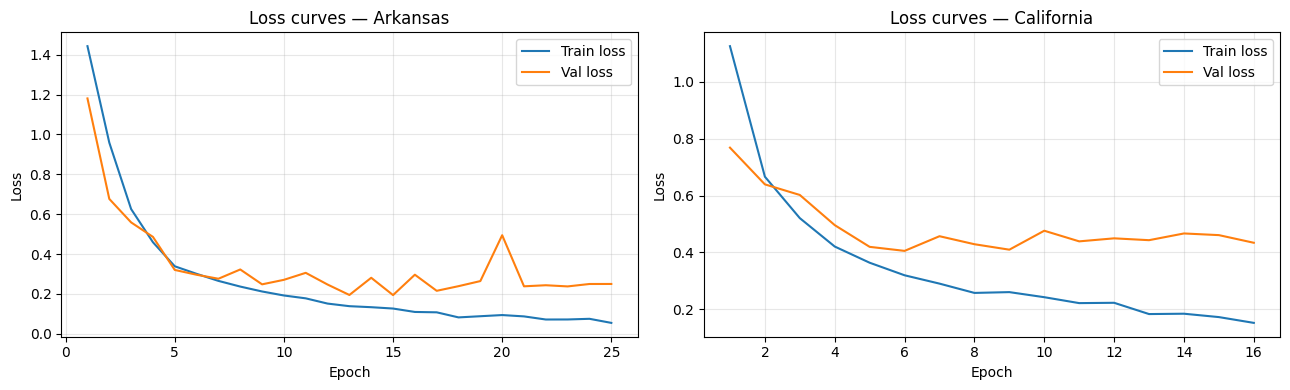


Arkansas
             Our result     Paper
OA           0.946          0.968
Kappa        0.918          0.951
F1-macro     0.855          0.933

California
             Our result     Paper
OA           0.914          0.852
Kappa        0.872          0.806
F1-macro     0.813          0.829


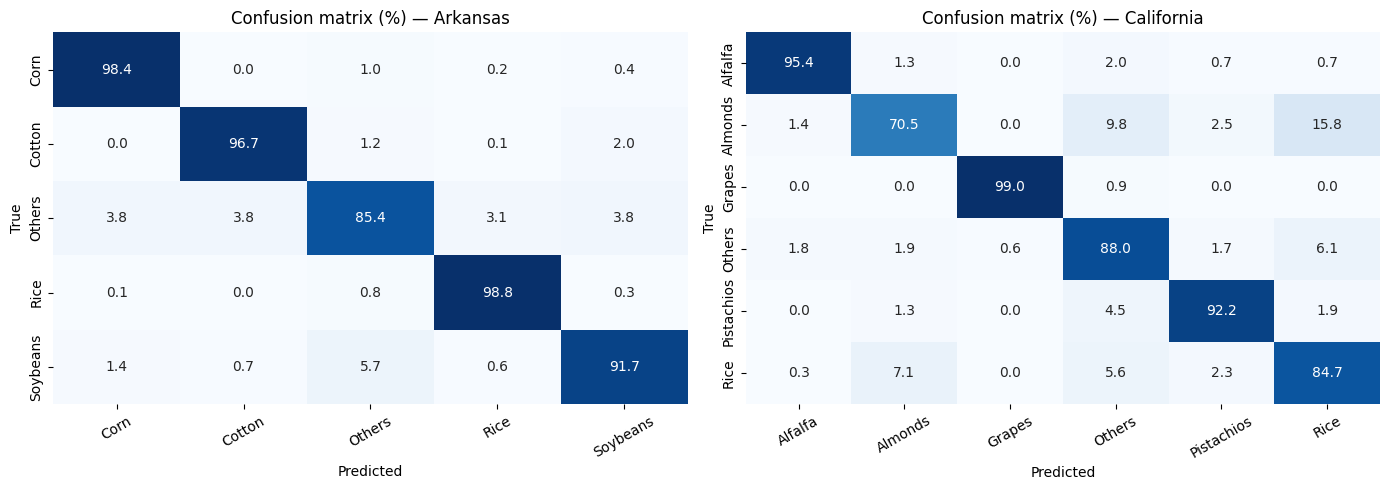


--- Classification report — Arkansas ---
              precision    recall  f1-score   support

        Corn      0.937     0.984     0.960      1020
      Cotton      0.954     0.967     0.960       752
      Others      0.277     0.854     0.418       130
        Rice      0.984     0.988     0.986      2130
    Soybeans      0.992     0.917     0.953      4468

    accuracy                          0.946      8500
   macro avg      0.829     0.942     0.855      8500
weighted avg      0.969     0.946     0.955      8500


--- Classification report — California ---
              precision    recall  f1-score   support

     Alfalfa      0.676     0.954     0.791       151
     Almonds      0.581     0.705     0.637       285
      Grapes      0.994     0.990     0.992      3171
      Others      0.961     0.880     0.919      3542
  Pistachios      0.604     0.922     0.730       154
        Rice      0.770     0.847     0.807      1047

    accuracy                          0.914  

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, history, region in zip(
    axes, [history_ar, history_ca], ['Arkansas', 'California']
):
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train loss')
    ax.plot(epochs, history['val_loss'],   label='Val loss')
    ax.set_title(f'Loss curves — {region}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


results = {}

for model, loaders, data, region, paper in [
    (model_ar, loaders_ar, data_ar, 'Arkansas',   PAPER_AR),
    (model_ca, loaders_ca, data_ca, 'California', PAPER_CA),
]:
    _, _, test_loader = loaders
    oa, kappa, f1, _, preds, labels = evaluate(model, test_loader)
    results[region] = {'OA': oa, 'Kappa': kappa, 'F1': f1,
                       'preds': preds, 'labels': labels, 'data': data}

    print(f'\n{region}')
    print(f'{"":<12} {"Our result":<14} {"Paper"}')
    print(f'{"OA":<12} {oa:.3f}          {paper["OA"]:.3f}')
    print(f'{"Kappa":<12} {kappa:.3f}          {paper["Kappa"]:.3f}')
    print(f'{"F1-macro":<12} {f1:.3f}          {paper["F1"]:.3f}')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, region in zip(axes, ['Arkansas', 'California']):
    r     = results[region]
    le    = r['data']['le']
    cm    = confusion_matrix(r['labels'], r['preds'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, cbar=False
    )
    ax.set_title(f'Confusion matrix (%) — {region}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


for region in ['Arkansas', 'California']:
    r  = results[region]
    le = r['data']['le']
    print(f'\n--- Classification report — {region} ---')
    print(classification_report(
        r['labels'], r['preds'],
        target_names=le.classes_, digits=3
    ))

## 9. Save Model

In [9]:
for model, data, history, region in [
    (model_ar, data_ar, history_ar, 'AR'),
    (model_ca, data_ca, history_ca, 'CA'),
]:
    path = os.path.join(SAVE_DIR, f'mctnet_{region}.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'le_classes':       data['le'].classes_,
        'norm_mean':        data['norm_mean'],
        'norm_std':         data['norm_std'],
        'history':          history,
        'n_bands':          N_BANDS,
        'n_classes':        len(data['le'].classes_),
        'n_heads':          N_HEADS,
        'kernel_size':      KERNEL_SIZE,
        'dropout':          DROPOUT,
        'n_timesteps':      N_TIMESTEPS,
    }, path)
    print(f'Saved: {path}')

Saved: C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Last-version\Data\mctnet_AR.pth
Saved: C:\Users\fatene\Desktop\TP-Res-Neur\Projet\Last-version\Data\mctnet_CA.pth
